# Gamma Functions

The Gamma function is a special function that generalizes the factorial to non-integer values. It is defined by

$$
\Gamma(x) = \int_0^\infty t^{x-1}e^{-t}\,dt,
$$

for $x>0$. For positive integers,

$$
\Gamma(n) = (n-1)!.
$$

Thus, the Gamma function extends the factorial beyond integer arguments. SciPy provides several functions related to the Gamma function, including the Gamma function itself, its logarithm, and the regularized incomplete Gamma functions.

In [1]:
from scipy import special
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

In [3]:
def plot_gamma(type="gamma", a=1, x_min=0.1, x_max=5, num=1000):
    x = np.linspace(x_min, x_max, num)
    if type == "gamma":
        vals = special.gamma(x)
        ylabel = r"$\Gamma(x)$"
    elif type == "gammaln":
        vals = special.gammaln(x)
        ylabel = r"$\ln \Gamma(x)$"
    elif type == "gammainc":
        vals = special.gammainc(a, x)
        ylabel = f"$P({a}, x)$"
    elif type == "gammaincc":
        vals = special.gammaincc(a, x)
        ylabel = f"$Q({a}, x)$"
    else:
        raise ValueError("Type is not recognized.")
    plt.figure(figsize=(5, 5))
    plt.plot(x, vals, "r")
    plt.xlabel(r"$x$")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## Gamma Function

The Gamma function can be evaluated using `special.gamma`. For example,

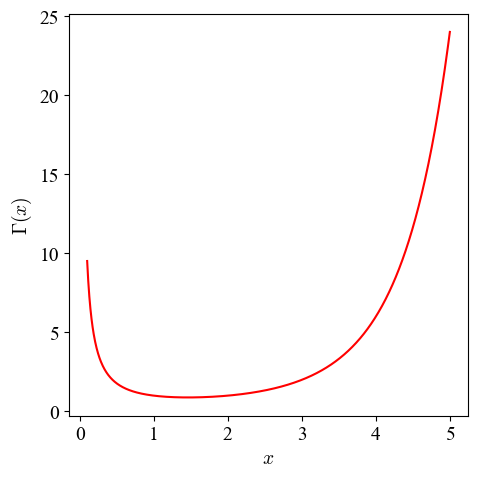

In [4]:
plot_gamma(type="gamma")

produces

$$
\Gamma(x).
$$

The Gamma function satisfies the recurrence relation

$$
\Gamma(x+1) = x\Gamma(x),
$$

which gives the factorial relation directly:

$$
\Gamma(n+1) = n!.
$$

## Logarithm of the Gamma Function

For large values of $x$, $\Gamma(x)$ grows very rapidly. Directly evaluating the Gamma function can therefore lead to numerical overflow. Its logarithm can be evaluated using `special.gammaln(x)` which corresponds to

$$
\ln\Gamma(x).
$$

For example,

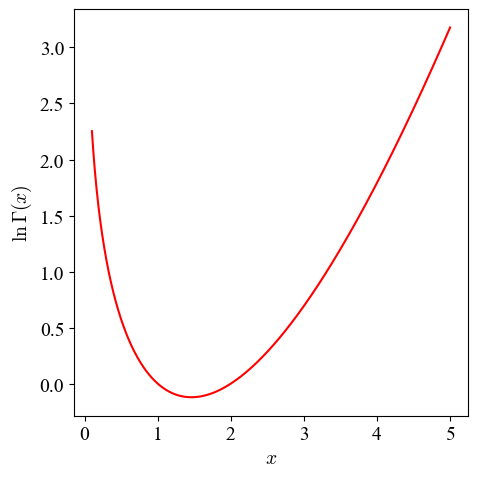

In [5]:
plot_gamma(type="gammaln")

provides a numerically more stable representation when Gamma functions become very large.

## Regularized Incomplete Gamma Function

The lower incomplete Gamma function is defined as

$$
\gamma(a,x) = \int_0^x t^{a-1}e^{-t}\,dt.
$$

Its regularized form is

$$
P(a,x) = \frac{\gamma(a,x)}{\Gamma(a)}.
$$

SciPy provides this function through `special.gammainc(a, x)`. For example,

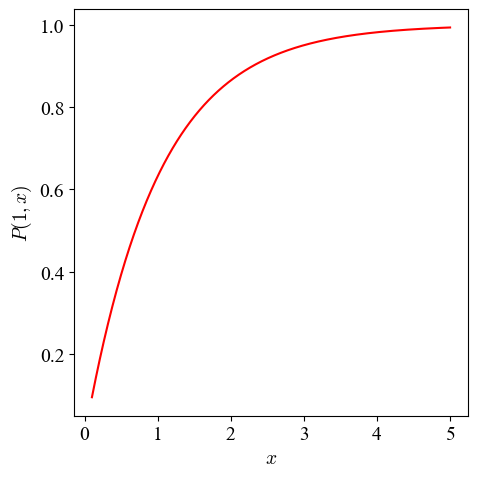

In [6]:
plot_gamma(type="gammainc")

gives

$$
P(a,x).
$$

For fixed $a>0$,

$$
P(a,0) = 0,\quad
\lim_{x\to\infty}P(a,x) = 1.
$$

## Complementary Regularized Incomplete Gamma Function

The upper incomplete Gamma function is

$$
\Gamma(a,x) = \int_x^\infty t^{a-1}e^{-t}\,dt.
$$

Its regularized form is

$$
Q(a,x) = \frac{\Gamma(a,x)}{\Gamma(a)}.
$$

SciPy provides it using `special.gammaincc(a, x)`. For example,

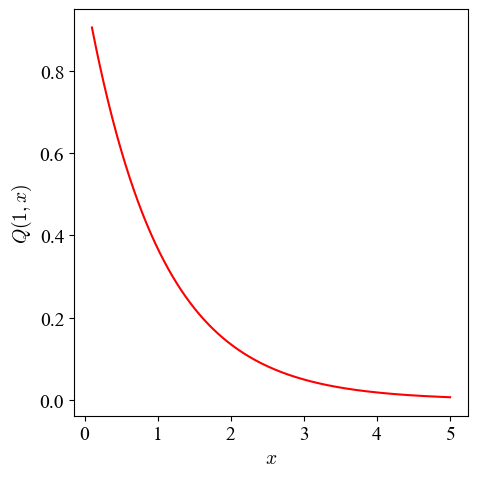

In [7]:
plot_gamma(type="gammaincc")

gives

$$
Q(a,x).
$$

The two regularized incomplete Gamma functions satisfy

$$
P(a,x) + Q(a,x) = 1.
$$

Therefore,

$$
P(a,x)
$$

represents the normalized contribution accumulated from $0$ to $x$, while

$$
Q(a,x)
$$

represents the remaining contribution from $x$ to $\infty$.